# Patient age & length-of-stay distributions

Basic EDA against `bronze.patient_information`. One row per surgery (`LOG_ID`).

Note: `BIRTH_DATE` is misleadingly named -- it's actually **age in years**, not a date
(confirmed via the official MOVER data dictionary, see `docs/DATA_DICTIONARY.md`).

In [17]:
import os

import duckdb
import matplotlib.pyplot as plt

WAREHOUSE = os.environ.get("MOVER_WAREHOUSE_DIR", "/work/iceberg_warehouse") + "/bronze"

con = duckdb.connect()
con.execute("INSTALL iceberg; LOAD iceberg; SET unsafe_enable_version_guessing = true;")
con.execute(
    f"CREATE OR REPLACE VIEW patient_information AS "
    f"SELECT * FROM iceberg_scan('{WAREHOUSE}/patient_information')"
)
con.sql("SELECT COUNT(*) AS n_surgeries FROM patient_information").show()

┌─────────────┐
│ n_surgeries │
│    int64    │
├─────────────┤
│       65728 │
└─────────────┘



In [18]:
df = con.execute(
    "SELECT LOG_ID, MRN, BIRTH_DATE AS age_years, LOS AS los_days "
    "FROM patient_information"
).df()

df.describe()

,age_years,los_days
count,65728.000000,65714.000000
mean,55.141340,7.387497
std,17.488542,14.262158
min,17.000000,0.000000
25%,42.000000,0.000000
50%,57.000000,2.000000
75%,68.000000,8.000000
max,90.000000,244.000000


## Age distribution (years)

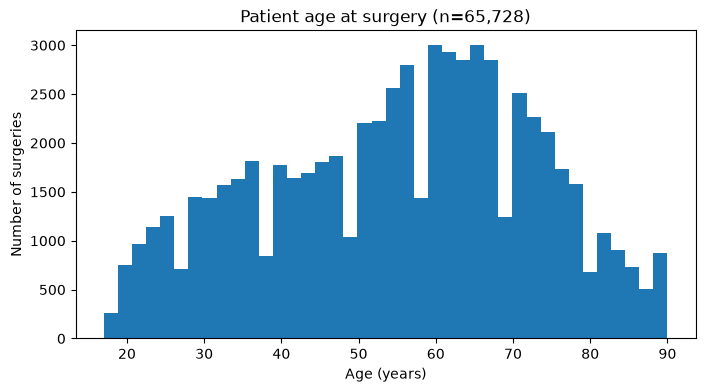

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
df["age_years"].plot.hist(bins=40, ax=ax)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of surgeries")
ax.set_title(f"Patient age at surgery (n={df['age_years'].notna().sum():,})")
plt.show()

## Length-of-stay distribution (days)

LOS is typically right-skewed (most stays short, a long tail of extended stays) --
plotted on both linear and log-x scales.

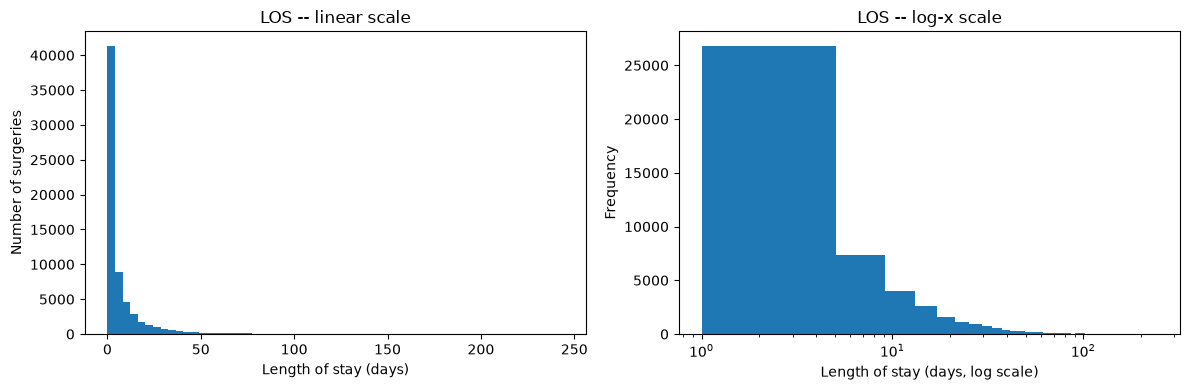

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["los_days"].plot.hist(bins=60, ax=axes[0])
axes[0].set_xlabel("Length of stay (days)")
axes[0].set_ylabel("Number of surgeries")
axes[0].set_title("LOS -- linear scale")

df[df["los_days"] > 0]["los_days"].plot.hist(bins=60, ax=axes[1], log=False)
axes[1].set_xscale("log")
axes[1].set_xlabel("Length of stay (days, log scale)")
axes[1].set_title("LOS -- log-x scale")

plt.tight_layout()
plt.show()

In [21]:
import platform, os
print(platform.system(), platform.node())
print(os.path.exists("/work"))

Linux ac6a207f1556
True


In [27]:
import
import duckdb
import matplotlib.pyplot as plt

WAREHOUSE = os.environ.get("MOVER_WAREHOUSE_DIR", "/work/iceberg_warehouse") + "/bronze"

con = duckdb.connect()
con.execute("INSTALL iceberg; LOAD iceberg; SET unsafe_enable_version_guessing = true;")
con.execute(
    f"CREATE OR REPLACE VIEW patient_medications AS "
    f"SELECT * FROM iceberg_scan('{WAREHOUSE}/patient_medications')"
)
con.sql("SELECT MEDICATION_NM, START_DATE, END_DATE FROM patient_medications LIMIT 25").show()

┌───────────────────────────────────────────────────────┬─────────────────────┬─────────────────────┐
│                     MEDICATION_NM                     │     START_DATE      │      END_DATE       │
│                        varchar                        │      timestamp      │      timestamp      │
├───────────────────────────────────────────────────────┼─────────────────────┼─────────────────────┤
│ PANCRELIPASE (LIP-PROT-AMYL) 3000-9500 UNITS PO CPEP  │ 2022-10-04 00:00:00 │ 2022-11-03 00:00:00 │
│ INSULIN LISPRO (HUMAN) 100 UNIT/ML SC SOLN (UCI)      │ 2022-12-17 00:00:00 │ 2022-12-24 00:00:00 │
│ TAMSULOSIN HCL 0.4 MG PO CAPS                         │ 2022-12-18 00:00:00 │ 2023-01-03 00:00:00 │
│ TAMSULOSIN HCL 0.4 MG PO CAPS                         │ 2022-12-18 00:00:00 │ 2023-01-03 00:00:00 │
│ K PHOS DI & MONO-SOD PHOS MONO 155-852-130 MG OR TABS │ 2022-12-18 00:00:00 │ 2022-12-18 00:00:00 │
│ NIFEDIPINE 30 MG OR TB24                              │ 2022-12-18 00:00:00 │ 20